# RRNN y PLN


En este notebook vamos a poner en juego **distintas soluciones de redes neuronales recurrentes (RRNN) en la tarea de clasificación de textos (PLN)**.

Entre las **tareas a realizar previamente con datos tipo texto** utilizaremos como **técnica de codificación una capa "embedding" que aprenderá de los propios datos.** Ademas utilizaremos **recursos comunes en estos casos** como **limitar el nº de palabras de interés** en la carga y **limitar** también **la longitud de las secuencias** (noticias)

El dataset que vamos a utilizar es uno ya disponible desde Tensorflow-Keras, **dataset real de noticias de la agencia "Reuters"**.

El **dataset de noticias de Reuters** contiene **11.228 textos que corresponden a noticias clasificadas en 46 categorías**. Los textos ya vienen codificados de forma que a cada palabra le corresponde un número entero (tokenizados)

## Inicialización y carga de datos

El siguiente código carga los paquetes necesarios para la práctica y lee los datos que utilizaremos para entrenar las redes neuronales.  Durante la carga de datos especificamos que queremos trabajar con 2.000 palabras, de forma que las palabras menos repetidas se considerarán desconocidas.

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

%matplotlib inline


from time import time


import warnings

warnings.filterwarnings('ignore')

Especificamos el **nº de palabras más frecuentes que vamos a recuperar de todas las noticias** en la carga:

In [ ]:
NUM_WORDS_LOAD = 2000
(reuters_train_x, reuters_train_y), (reuters_test_x, reuters_test_y) = tf.keras.datasets.reuters.load_data(num_words=NUM_WORDS_LOAD)

2110848/2110848 [==============================] - 1s 1us/step


Comprobamos el nº de clases y mostramos por interés la primera noticia:

In [ ]:
n_labels = np.unique(reuters_train_y).shape[0]
print(f"Número de clases: {n_labels}")

Número de clases: 46


In [ ]:
# Mostramos la primera noticia, nos devuelve los índices de las palabras en el VOCABULARIO formado
print(reuters_train_x[0])

[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 2, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 2, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]


## 1. Modelo base: Red LSTM simple

En este apartado implementaremos el **modelo base** con una **red neuronal recurrente de tipo LSTM con una única capa**. La entrada de la red serán las palabras codificadas en valores enteros, y añadiremos **una capa de embedding para que la red aprenda una representación densa de las palabras** , muy útil y frecuente en la tarea de clasificación.

**Para trabajar con una red neuronal recurrente es costumbre definir una longitud fija para todos los textos** (secuencias). Los textos más largos que la longitud predefinida se recortarán y los textos más cortos se ampliarán con un valor prefijado, que se suele denominar *pad*.

El siguiente código utiliza funciones de preprocesamiento de Keras para preparar las secuencias de texto con una longitud de secuencia de 30 palabras.

In [ ]:
from tensorflow.keras.utils import pad_sequences

reuters_train_x_30 = pad_sequences(reuters_train_x, maxlen=30)
reuters_test_x_30 = pad_sequences(reuters_test_x, maxlen=30)

 Vamos a implementar la red con **una única capa LSTM con 10 unidades**. La entrada de la red debe pasar por una **capa de embedding con 10 dimensiones** antes de entrar en cada celda LSTM. En la salida de la capa recurrente hay que añadir **una capa densa para ajustar el número de salidas al número de categorías (clasificador).**

In [ ]:
import keras

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM



In [ ]:
# categórica con mismo formato salida 'softmax'
reuters_train_y_cat = to_categorical(reuters_train_y, n_labels)
reuters_test_y_cat = to_categorical(reuters_test_y, n_labels)


In [ ]:
embed_dimensiones = 10

# creamos modelo

modelo1 = Sequential()
modelo1.add(Embedding(NUM_WORDS_LOAD, embed_dimensiones))
modelo1.add(LSTM(10))
modelo1.add(Dense(n_labels, activation="softmax"))

# compilamos modelo
modelo1.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])


 **Por precaución del tiempo** y siendo **modelo base** vamos a **entrenar la red** durante **20 épocas**, utilizando el conjunto de test como validación y visualizaremos las curvas de la función de pérdida ("loss") y de "accuracy" durante el entrenamiento.

Comprobamos presencia de acelerador gráfico.

In [ ]:
## TensorFlow 2.x
#%tensorflow_version 2.x
#import tensorflow as tf

print("TF version   : ", tf.__version__)
print("GPU available: ", tf.config.list_physical_devices('GPU'))

TF version   :  2.14.0
GPU available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Entrenamos el modelo:

In [ ]:
n_epochs = 20

modelo1fit = modelo1.fit(reuters_train_x_30, reuters_train_y_cat, \
                         validation_data=(reuters_test_x_30, reuters_test_y_cat), epochs=n_epochs, batch_size=128, verbose=2)



Epoch 1/20
71/71 - 14s - loss: 3.3826 - accuracy: 0.3445 - val_loss: 2.8617 - val_accuracy: 0.3620 - 14s/epoch - 194ms/step
Epoch 2/20
71/71 - 3s - loss: 2.6414 - accuracy: 0.3517 - val_loss: 2.4936 - val_accuracy: 0.3620 - 3s/epoch - 37ms/step
Epoch 3/20
71/71 - 2s - loss: 2.4443 - accuracy: 0.3517 - val_loss: 2.4246 - val_accuracy: 0.3620 - 2s/epoch - 27ms/step
Epoch 4/20
71/71 - 2s - loss: 2.3908 - accuracy: 0.3517 - val_loss: 2.3475 - val_accuracy: 0.3620 - 2s/epoch - 22ms/step
Epoch 5/20
71/71 - 1s - loss: 2.2644 - accuracy: 0.3517 - val_loss: 2.2032 - val_accuracy: 0.3620 - 682ms/epoch - 10ms/step
Epoch 6/20
71/71 - 1s - loss: 2.1586 - accuracy: 0.3517 - val_loss: 2.1202 - val_accuracy: 0.3620 - 935ms/epoch - 13ms/step
Epoch 7/20
71/71 - 1s - loss: 2.0832 - accuracy: 0.3696 - val_loss: 2.0747 - val_accuracy: 0.3811 - 1s/epoch - 16ms/step
Epoch 8/20
71/71 - 1s - loss: 2.0315 - accuracy: 0.3874 - val_loss: 2.0420 - val_accuracy: 0.3994 - 619ms/epoch - 9ms/step
Epoch 9/20
71/71 - 1s

In [ ]:
# función para graficar curvas train/validation del entrenamiento

def plot_train_results(history):

    # Visualizamos la evolución de la accuracy
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='lower right')
    plt.grid = True
    plt.show()

    # Visualizamos la evolución del error cometido por la red
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper right')
    plt.grid = True
    plt.show()

Grafica con los resultados:

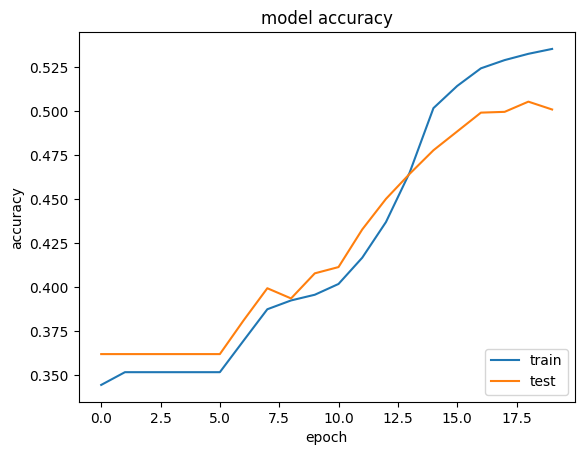

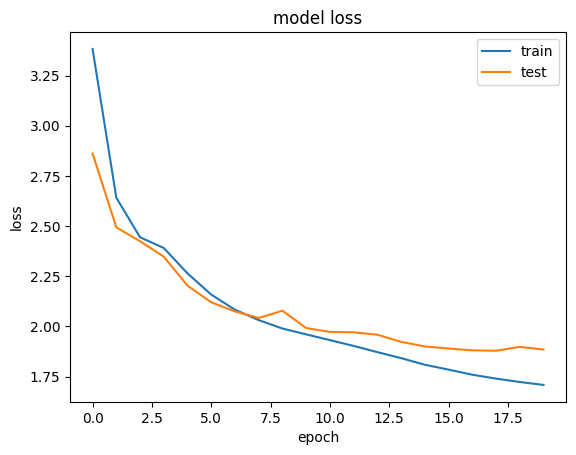

In [ ]:
plot_train_results(modelo1fit)

Dado el nº de epochs elegido vemos que tanto para la **precisión** como para la **función de coste** la curva sigue aumentando (caso precisión) y disminuyendo (caso función de pérdida).

Los valores alcanzados son de 0.53 y de 1.8 aproximadamente, en la precisión y pérdida respectivamente. Dado que lo tomamos como base nos quedamos aquí solo con los valores de las curvas.

Como futuras propuestas  para mejorar estos **bajos valores de desempeño** tendríamos **aumentar el tamaño máximo fijado en los textos de entrenamiento de 30 palabras**, aumentar las dimensiones de la red, **se podría probar con añadir más unidades a la capa LSTM, incluso alguna capa más (redes profundas)o aumentar también las dimensiones del 'embedding'** y comprobar los resultados.


## 2. Redes LSTM profundas

En este apartado **probaremos a añadir más capas y a variar la longitud de las secuencias**, y ver los resultados.

Implementaremos diferentes redes neuronales con **dos capas LSTM**. **Todas las redes tendrán exactamente la misma arquitectura y número de parámetros, pero las entrenaremos con secuencias de diferente longitud.**

Esto permitirá analizar cuál es el efecto de la longitud en la precisión de la clasificación de las noticias, y también del aumneto de capas.

Concretamente, la arquitectura que utilizaremos es la siguiente:

- Capa de entrada con secuencias de longitud L.
- Capa de *embedding* con 32 unidades.
- Capa LSTM con 32 unidades.
- Capa LSTM con 32 unidades.
- Capa completamente conectada con 46 neuronas.

Probaremos con las longitudes: 10, 20, 30, 50, 100, 150, 200 y 250.

**IMPORTANTE:** este ejercicio puede tardar horas en ejecutarse. Se reomienda programar el ejercicio con una submuestra pequeña del conjunto de datos. Una vez estéis seguros de que todo funciona correctamente podéis lanzar el proceso con el conjunto de datos completo para hacer el análisis de los resultados.


#### MODELO ÚNICO

In [ ]:
embed_dimensiones = 32

# creamos modelo único

modelo2 = Sequential()
modelo2.add(Embedding(NUM_WORDS_LOAD, embed_dimensiones))

#  Al apilar capas RNN en Keras, las intermedias deben tener parámetro 'return_sequences' igual a True
modelo2.add(LSTM(32,return_sequences=True))
modelo2.add(LSTM(32))

modelo2.add(Dense(n_labels, activation="softmax"))

# compilamos modelo
modelo2.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])


#### PRUEBA CON SUBMUESTRA

In [ ]:
reuters_train_x_30.shape, reuters_test_x_30.shape

((8982, 30), (2246, 30))

In [ ]:
# recortamosa una muestra mas pequeña
reuters_train_x_30_prueba = reuters_train_x_30[:450,:]
reuters_test_x_30_prueba = reuters_test_x_30[:110,:]

reuters_train_x_30_prueba.shape, reuters_test_x_30_prueba.shape

((450, 30), (110, 30))

In [ ]:
# idem con las salidas

reuters_train_y_cat_prueba = reuters_train_y_cat[:450,:]
reuters_test_y_cat_prueba = reuters_test_y_cat[:110,:]

reuters_train_y_cat_prueba.shape, reuters_test_y_cat_prueba.shape

((450, 46), (110, 46))

Probamos entrenamiento con submuestra:

In [ ]:
n_epochs = 20

modelo2fitprueba = modelo2.fit(reuters_train_x_30_prueba, reuters_train_y_cat_prueba, \
                         validation_data=(reuters_test_x_30_prueba, reuters_test_y_cat_prueba), epochs=n_epochs, batch_size=128, verbose=2)



Epoch 1/20
4/4 - 4s - loss: 3.8067 - accuracy: 0.2533 - val_loss: 3.7518 - val_accuracy: 0.3455 - 4s/epoch - 1s/step
Epoch 2/20
4/4 - 0s - loss: 3.6732 - accuracy: 0.3444 - val_loss: 3.4011 - val_accuracy: 0.3455 - 478ms/epoch - 120ms/step
Epoch 3/20
4/4 - 0s - loss: 3.1359 - accuracy: 0.3444 - val_loss: 2.9060 - val_accuracy: 0.3455 - 484ms/epoch - 121ms/step
Epoch 4/20
4/4 - 0s - loss: 2.7530 - accuracy: 0.3444 - val_loss: 2.7559 - val_accuracy: 0.3455 - 377ms/epoch - 94ms/step
Epoch 5/20
4/4 - 0s - loss: 2.6087 - accuracy: 0.3444 - val_loss: 2.6673 - val_accuracy: 0.3455 - 474ms/epoch - 119ms/step
Epoch 6/20
4/4 - 0s - loss: 2.5213 - accuracy: 0.3444 - val_loss: 2.6095 - val_accuracy: 0.3455 - 271ms/epoch - 68ms/step
Epoch 7/20
4/4 - 0s - loss: 2.4655 - accuracy: 0.3444 - val_loss: 2.5723 - val_accuracy: 0.3455 - 472ms/epoch - 118ms/step
Epoch 8/20
4/4 - 0s - loss: 2.4251 - accuracy: 0.3444 - val_loss: 2.5451 - val_accuracy: 0.3455 - 371ms/epoch - 93ms/step
Epoch 9/20
4/4 - 0s - los

Vemos que no se han producido errores

#### MODELO ÚNICO CON DISTINTAS LONGITUDES DE TEXTO

In [ ]:
# inicialización longitudes pedidas y lista con modelos para graficar después
longitudes_texto = [10, 20, 30, 50, 100, 150, 200, 250]
modelos_L = []

# entrenamiento con distintas longitudes
for L in longitudes_texto:

    # entrenamos con mismo conjunto de noticias, variando longitud máxima (L)
    reuters_train_x_L = pad_sequences(reuters_train_x, maxlen=L)
    reuters_test_x_L = pad_sequences(reuters_test_x, maxlen=L)

    # entrenamiento y evaluacion
    start_time = time()
    modeloLfit = modelo2.fit(reuters_train_x_L, reuters_train_y_cat, \
                             validation_data=(reuters_test_x_L, reuters_test_y_cat), \
                             epochs=n_epochs, batch_size=128, verbose=0)
    tiempo_entrenL = time() - start_time

    loss_L, acc_L = modelo2.evaluate(reuters_test_x_L, reuters_test_y_cat,batch_size=128)

    # guardar modelos entrenados para la representación gráfica
    modelos_L.append(modeloLfit)

    # presentar resultados modelo
    print(f'Modelo entrenado con longitud de textos: {str(L)}', '\n')
    print(f'Precision: {acc_L}','\t'*2, f'Perdida(loss): {loss_L}', '\t'*2, f'Tiempo entrenamiento: {tiempo_entrenL}', '\n'*2)





18/18 [==============================] - 0s 3ms/step - loss: 1.9864 - accuracy: 0.5018
Modelo entrenado con longitud de textos: 10 

Precision: 0.5017809271812439 		 Perdida(loss): 1.9864094257354736 		 Tiempo entrenamiento: 20.5019850730896 


18/18 [==============================] - 0s 4ms/step - loss: 1.9896 - accuracy: 0.5499
Modelo entrenado con longitud de textos: 20 

Precision: 0.5498664379119873 		 Perdida(loss): 1.989558458328247 		 Tiempo entrenamiento: 22.39593005180359 


18/18 [==============================] - 0s 4ms/step - loss: 2.2226 - accuracy: 0.5543
Modelo entrenado con longitud de textos: 30 

Precision: 0.5543187856674194 		 Perdida(loss): 2.2226145267486572 		 Tiempo entrenamiento: 22.52742886543274 


18/18 [==============================] - 0s 4ms/step - loss: 2.3322 - accuracy: 0.5761
Modelo entrenado con longitud de textos: 50 

Precision: 0.5761353373527527 		 Perdida(loss): 2.332227945327759 		 Tiempo entrenamiento: 27.976882219314575 


18/18 [===========

Vamos a crear **dos gráficas**, una con la **evolución de la función de pérdida** para los conjuntos de test **de las diferentes redes (longitudes de texto)** y la otra con la **evolución del "accuracy"** para los mismos conjuntos.


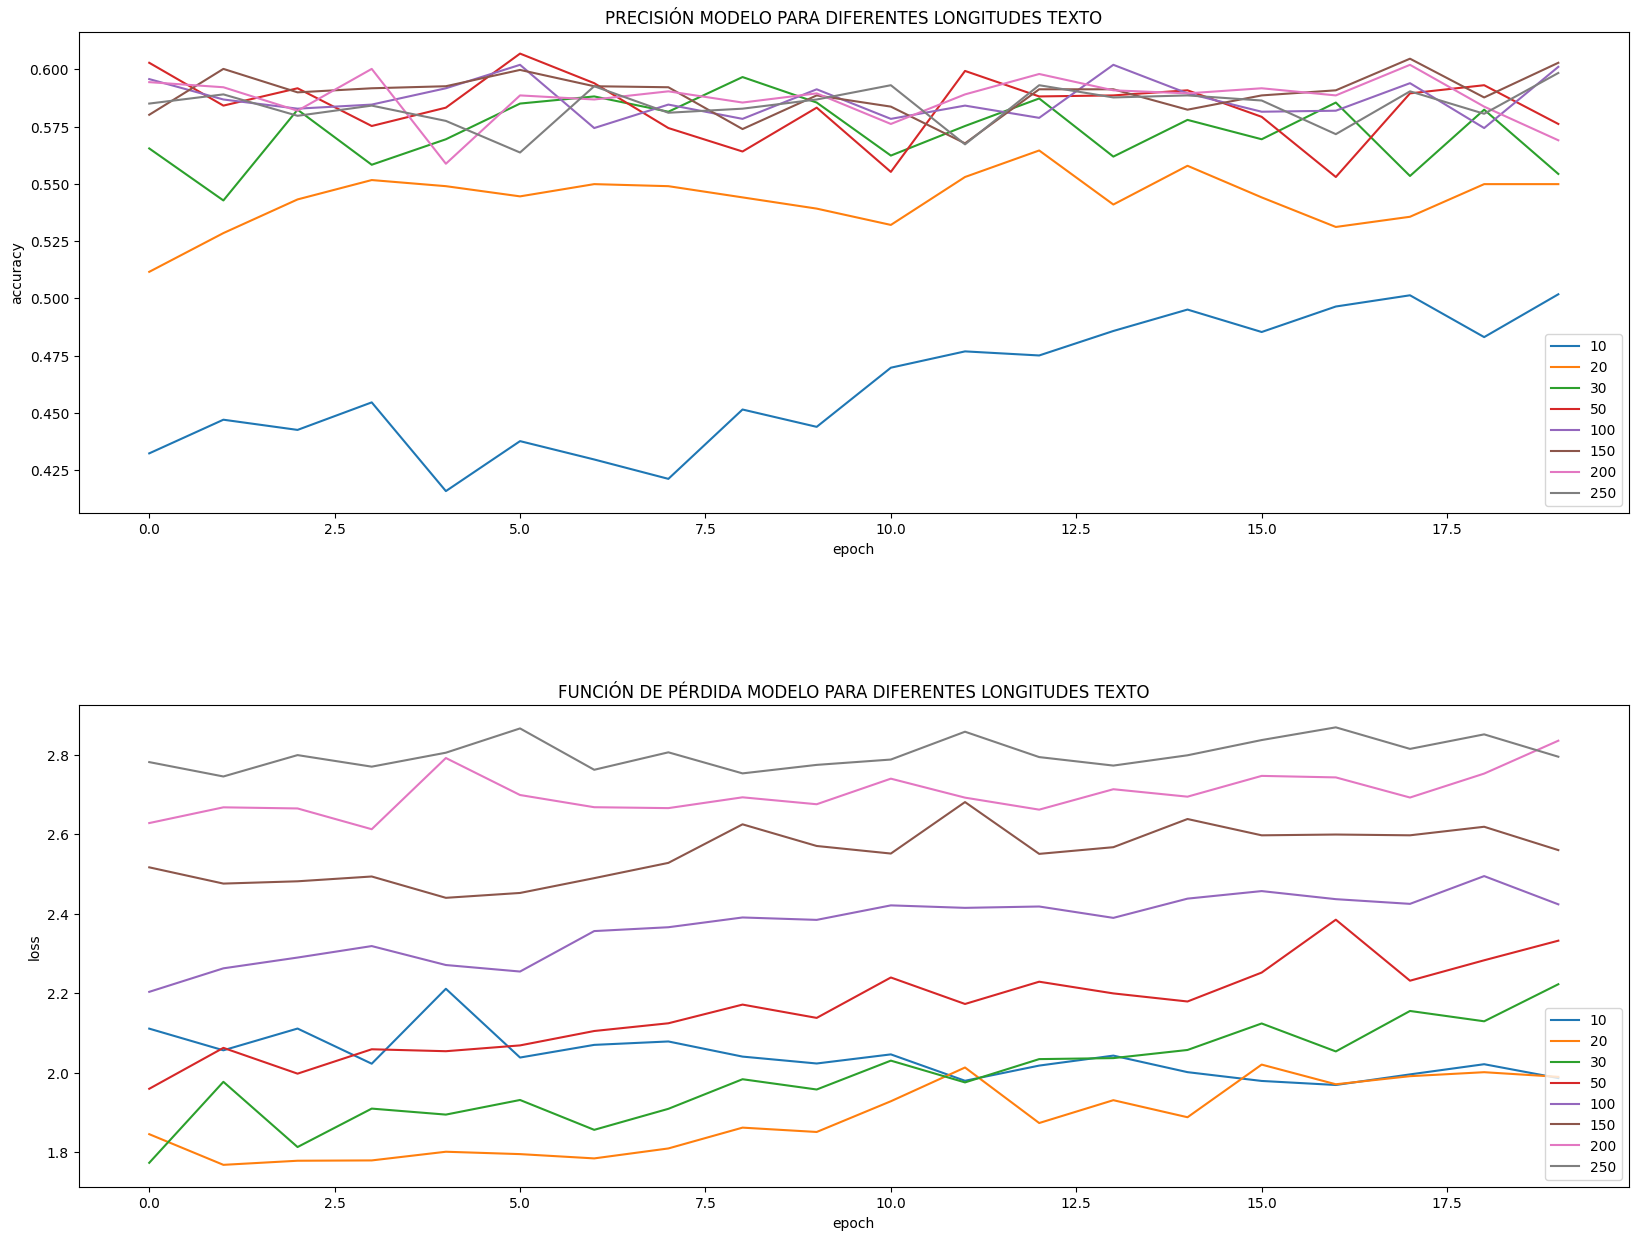

In [ ]:
# creamos la grafica
fig, axes = plt.subplots(2, 1, figsize=(20, 15),gridspec_kw={'hspace': 0.4})
ax = axes.ravel()

for modelo in modelos_L:
    # precision y 'loss' conjunto test
    ax[0].plot(modelo.history['val_accuracy'])
    ax[1].plot(modelo.history['val_loss'])


# configuraciones graficas
ax[0].set_title('PRECISIÓN MODELO PARA DIFERENTES LONGITUDES TEXTO')
ax[0].set_ylabel('accuracy')
ax[0].set_xlabel('epoch')
ax[0].legend(longitudes_texto, loc='best')

ax[1].set_title('FUNCIÓN DE PÉRDIDA MODELO PARA DIFERENTES LONGITUDES TEXTO')
ax[1].set_ylabel('loss')
ax[1].set_xlabel('epoch')
ax[1].legend(longitudes_texto, loc='best')


plt.show()

 Vamos a analizar los resultados obtenidos teniendo en cuenta la relación entre el rendimiento de los modelos y el tiempo de ejecución.

En cuanto a los **valores de precisión alcanzados según la longitud máxima de texto elegido, se observa una clara diferencia entre los 2 valores menores de la gama probada (10,20) y los 5 restantes**.

A partir de 30 los valores de precisión son muy similares. Vistas las curvas se puede afirmar entonces que **a partir de longitud máxima 100 hasta la de 250 probada y para la red proporcionada, que los valores de precisión son los prácticamente los mismos**.

Eso si, **los tiempos respectivos de entrenamiento con unidades de procesamiento gratuitas aumentan con cada paso (se probaron por tiempo solo las primeras) entre 300 y 400 segundos (entre 5 y casi 7 minutos).**

Teniendo en cuenta todo lo anterior podríamos concluir que **para una red determinada (fijadas arquitectura y parámetros restantes) la longitud máxima de los textos es un factor a tener en cuenta, pero que según el caso no siempre aumentos de esta longitud van a arrojar mejorías apreciables en la precisión que puedan justificar el aumento en el tiempo de entrenamiento.**


Calculamos los valores que devuelve el último modelo entrenado del bucle (n=250):

In [ ]:
loss_L, acc_L = modelo2.evaluate(reuters_test_x_L, reuters_test_y_cat)

print('Precision: {}'.format(acc_L),'\t'*2, 'Perdida(loss): {}'.format(loss_L))



71/71 [==============================] - 1s 8ms/step - loss: 2.7952 - accuracy: 0.5984
Precision: 0.5983971357345581 		 Perdida(loss): 2.7951884269714355


## 3. Redes BIDIRECCIONALES

En este apartado partimos del **mismo modelo y sus dimensiones pero** ahora con **capas bidireccionales**

Para poder comparar probaremos tambien las mismas longitudes de texto.

**IMPORTANTE:** este ejercicio puede tardar horas en ejecutarse. Se reomienda programar el ejercicio con una submuestra pequeña del conjunto de datos. Una vez estéis seguros de que todo funciona correctamente podéis lanzar el proceso con el conjunto de datos completo para hacer el análisis de los resultados.


#### MODELO ÚNICO

In [ ]:
from keras.layers import Bidirectional

embed_dimensiones = 32

# creamos modelo único

modelo3 = Sequential()
modelo3.add(Embedding(NUM_WORDS_LOAD, embed_dimensiones))

#  Al apilar capas RNN en Keras, las intermedias deben tener parámetro 'return_sequences' igual a True
modelo3.add(Bidirectional(LSTM(32,return_sequences=True)))
modelo3.add(Bidirectional(LSTM(32)))

modelo3.add(Dense(n_labels, activation="softmax"))

# compilamos modelo
modelo3.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])


#### PRUEBA CON SUBMUESTRA

In [ ]:
reuters_train_y_cat_prueba.shape, reuters_test_y_cat_prueba.shape

((450, 46), (110, 46))

Probamos entrenamiento con submuestra:

In [ ]:
n_epochs = 20

modelo3fitprueba = modelo3.fit(reuters_train_x_30_prueba, reuters_train_y_cat_prueba, \
                         validation_data=(reuters_test_x_30_prueba, reuters_test_y_cat_prueba), epochs=n_epochs, batch_size=128, verbose=2)



Epoch 1/20
4/4 - 7s - loss: 3.7960 - accuracy: 0.2756 - val_loss: 3.7075 - val_accuracy: 0.3455 - 7s/epoch - 2s/step
Epoch 2/20
4/4 - 0s - loss: 3.5776 - accuracy: 0.3489 - val_loss: 3.1380 - val_accuracy: 0.3455 - 297ms/epoch - 74ms/step
Epoch 3/20
4/4 - 0s - loss: 2.8003 - accuracy: 0.3444 - val_loss: 2.5944 - val_accuracy: 0.3455 - 356ms/epoch - 89ms/step
Epoch 4/20
4/4 - 0s - loss: 2.4338 - accuracy: 0.3444 - val_loss: 2.5303 - val_accuracy: 0.3455 - 308ms/epoch - 77ms/step
Epoch 5/20
4/4 - 0s - loss: 2.3758 - accuracy: 0.3444 - val_loss: 2.5062 - val_accuracy: 0.3455 - 257ms/epoch - 64ms/step
Epoch 6/20
4/4 - 0s - loss: 2.3411 - accuracy: 0.3444 - val_loss: 2.4746 - val_accuracy: 0.3455 - 303ms/epoch - 76ms/step
Epoch 7/20
4/4 - 0s - loss: 2.3017 - accuracy: 0.3444 - val_loss: 2.4119 - val_accuracy: 0.3455 - 356ms/epoch - 89ms/step
Epoch 8/20
4/4 - 0s - loss: 2.2601 - accuracy: 0.3600 - val_loss: 2.3659 - val_accuracy: 0.3455 - 315ms/epoch - 79ms/step
Epoch 9/20
4/4 - 0s - loss: 2

Vemos que no se han producido errores

#### MODELO ÚNICO CON DISTINTAS LONGITUDES DE TEXTO

In [ ]:
# inicialización longitudes pedidas y lista con modelos para graficar después
longitudes_texto = [10, 20, 30, 50, 100, 150, 200, 250]
modelos3_L = []

# entrenamiento con distintas longitudes
for L in longitudes_texto:

    # entrenamos con mismo conjunto de noticias, variando longitud máxima (L)
    reuters_train_x_L = pad_sequences(reuters_train_x, maxlen=L)
    reuters_test_x_L = pad_sequences(reuters_test_x, maxlen=L)

    # entrenamiento y evaluacion
    start_time = time()
    modeloLfit = modelo3.fit(reuters_train_x_L, reuters_train_y_cat, \
                             validation_data=(reuters_test_x_L, reuters_test_y_cat), \
                             epochs=n_epochs, batch_size=128, verbose=0)
    tiempo_entrenL = time() - start_time

    loss_L, acc_L = modelo3.evaluate(reuters_test_x_L, reuters_test_y_cat,batch_size=128)

    # guardar modelos entrenados para la representación gráfica
    modelos3_L.append(modeloLfit)

    # presentar resultados modelo
    print(f'Modelo entrenado con longitud de textos: {str(L)}', '\n')
    print(f'Precision: {acc_L}','\t'*2, f'Perdida(loss): {loss_L}', '\t'*2, f'Tiempo entrenamiento: {tiempo_entrenL}', '\n'*2)





18/18 [==============================] - 0s 4ms/step - loss: 2.0858 - accuracy: 0.4822
Modelo entrenado con longitud de textos: 10 

Precision: 0.4821905493736267 		 Perdida(loss): 2.085820436477661 		 Tiempo entrenamiento: 22.903689861297607 


18/18 [==============================] - 0s 5ms/step - loss: 2.1148 - accuracy: 0.5445
Modelo entrenado con longitud de textos: 20 

Precision: 0.5445235967636108 		 Perdida(loss): 2.114793539047241 		 Tiempo entrenamiento: 22.6072096824646 


18/18 [==============================] - 0s 5ms/step - loss: 2.0931 - accuracy: 0.5695
Modelo entrenado con longitud de textos: 30 

Precision: 0.5694568157196045 		 Perdida(loss): 2.0930984020233154 		 Tiempo entrenamiento: 23.36940908432007 


18/18 [==============================] - 0s 6ms/step - loss: 2.1198 - accuracy: 0.5886
Modelo entrenado con longitud de textos: 50 

Precision: 0.5886019468307495 		 Perdida(loss): 2.1198298931121826 		 Tiempo entrenamiento: 29.77033019065857 


18/18 [===========

Comparando con el apartado anterior vemos que **los tiempos de entrenamiento son mayores y se alcanzan valores de "accuracy" en TEST muy ligeramente superiores (0.61 frente a 0.59). Todo esto es debido a las capas BIDIRECTIONAL**

Vamos a crear **dos gráficas**, una con la **evolución de la función de pérdida** para los conjuntos de test **de las diferentes redes (longitudes de texto)** y la otra con la **evolución del "accuracy"** para los mismos conjuntos.


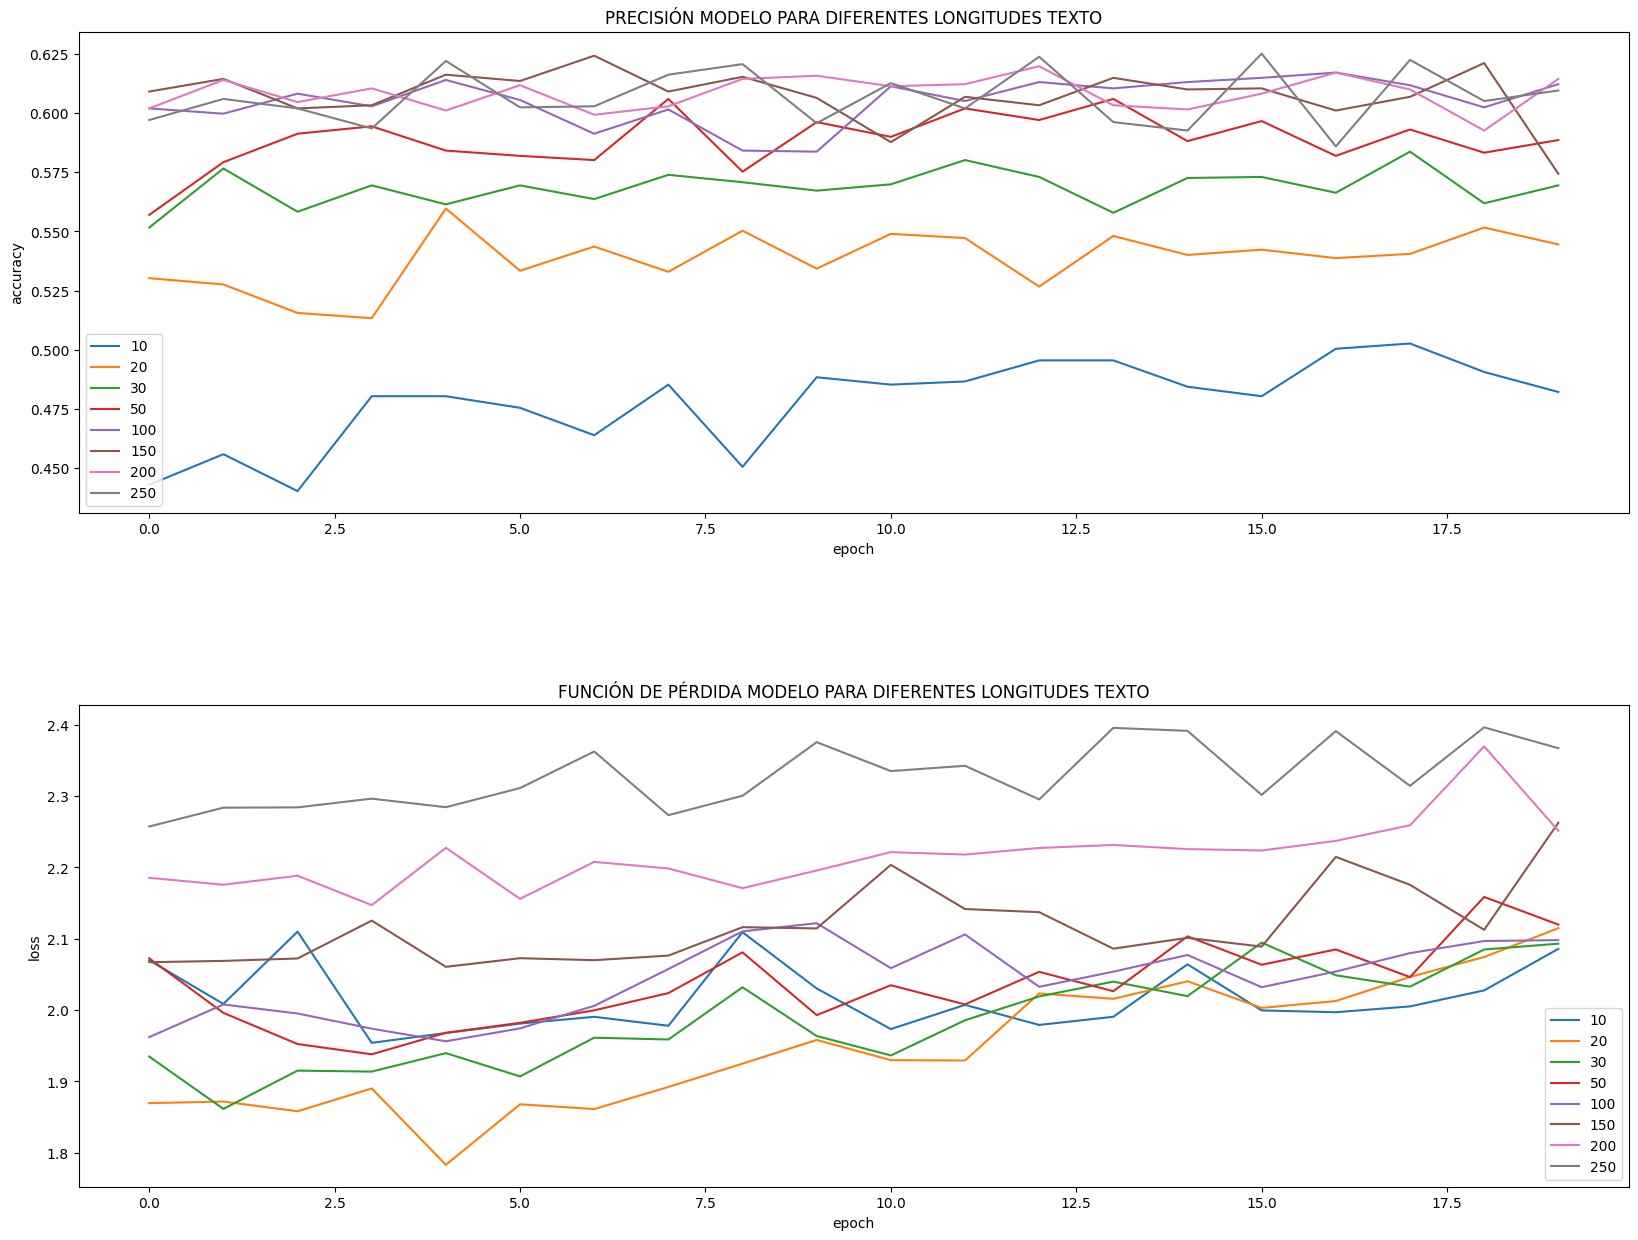

In [ ]:
# creamos la grafica
fig, axes = plt.subplots(2, 1, figsize=(20, 15),gridspec_kw={'hspace': 0.4})
ax = axes.ravel()

for modelo in modelos3_L:
    # precision y 'loss' conjunto test
    ax[0].plot(modelo.history['val_accuracy'])
    ax[1].plot(modelo.history['val_loss'])


# configuraciones graficas
ax[0].set_title('PRECISIÓN MODELO PARA DIFERENTES LONGITUDES TEXTO')
ax[0].set_ylabel('accuracy')
ax[0].set_xlabel('epoch')
ax[0].legend(longitudes_texto, loc='best')

ax[1].set_title('FUNCIÓN DE PÉRDIDA MODELO PARA DIFERENTES LONGITUDES TEXTO')
ax[1].set_ylabel('loss')
ax[1].set_xlabel('epoch')
ax[1].legend(longitudes_texto, loc='best')


plt.show()

**Las conclusiones son similares al apartado anterior. Poca diferencia a partir de longitud 50 hacia arriba**


Calculamos los valores que devuelve el último modelo entrenado del bucle (n=250):

In [ ]:
loss_L, acc_L = modelo3.evaluate(reuters_test_x_L, reuters_test_y_cat)

print('Precision: {}'.format(acc_L),'\t'*2, 'Perdida(loss): {}'.format(loss_L))



71/71 [==============================] - 1s 14ms/step - loss: 2.3671 - accuracy: 0.6095
Precision: 0.6095280647277832 		 Perdida(loss): 2.3670949935913086


## 4. BÚSQUEDA MEJOR MODELO

**Como punto final** en este apartado **se les muestra el resultado final de varias pruebas** (por cuestión de tiempo en el entrenamiento) según los siguientes puntos:

- Dada la complejidad de la tarea (46 clases), en previsión de aumentar las dimensiones de la red y el coste en tiempo del entrenamiento que supondrían sucesivas pruebas, decidimos tomar como longitud máxima de texto inicial 300.

- Elegimos como celda LSTM por tener mejor desempeño que la GRU en labores de clasificación complejas (nº alto de textos, diferenciar entre 46 clases).

- Aumentando inicialmente las unidades de cada capa (de 32 a 64), probamos con una sola capa y luego con 2, observandose ligera mejoría.

- Manteniendo las 2 capas fuimos aumentando el número de unidades de cada capa. Aumentamos al mismo tiempo la dimensión de 'embedding' para una mayor "representatividad" de las palabras que pudiera ayudar en la clasificación. Llegamos finalmente con una dimensión de embedding de 512, una primera capa de 512 unidades y la segunda de 256.

Con esta configuración **alcanzamos una precisión del 73.78 %**

In [ ]:
# longitud máxima textos 300
reuters_train_x_300 = pad_sequences(reuters_train_x, maxlen=300)
reuters_test_x_300 = pad_sequences(reuters_test_x, maxlen=300)


embed_dimensiones = 512

# creamos modelo único

modelo4 = Sequential()
modelo4.add(Embedding(NUM_WORDS_LOAD, embed_dimensiones))

#  capas RRNN en Keras
modelo4.add(Bidirectional(LSTM(512,return_sequences=True)))
modelo4.add(Bidirectional(LSTM(256)))

modelo4.add(Dense(n_labels, activation="softmax"))

# compilamos modelo
modelo4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])




In [ ]:
n_epochs = 20

modelo4_fit = modelo4.fit(reuters_train_x_300, reuters_train_y_cat, \
                           validation_data=(reuters_test_x_300, reuters_test_y_cat), epochs=n_epochs, batch_size=128, verbose=1)



Epoch 1/20
71/71 [==============================] - 17s 158ms/step - loss: 2.1773 - accuracy: 0.4589 - val_loss: 1.9770 - val_accuracy: 0.5036
Epoch 2/20
71/71 [==============================] - 9s 124ms/step - loss: 1.7098 - accuracy: 0.5701 - val_loss: 1.6349 - val_accuracy: 0.5882
Epoch 3/20
71/71 [==============================] - 7s 99ms/step - loss: 1.4594 - accuracy: 0.6355 - val_loss: 1.5785 - val_accuracy: 0.6162
Epoch 4/20
71/71 [==============================] - 7s 92ms/step - loss: 1.3576 - accuracy: 0.6632 - val_loss: 1.4714 - val_accuracy: 0.6505
Epoch 5/20
71/71 [==============================] - 7s 95ms/step - loss: 1.2452 - accuracy: 0.6902 - val_loss: 1.3488 - val_accuracy: 0.6603
Epoch 6/20
71/71 [==============================] - 6s 88ms/step - loss: 1.1635 - accuracy: 0.7081 - val_loss: 1.4060 - val_accuracy: 0.6536
Epoch 7/20
71/71 [==============================] - 6s 81ms/step - loss: 1.0864 - accuracy: 0.7233 - val_loss: 1.2785 - val_accuracy: 0.6830
Epoch 8/20

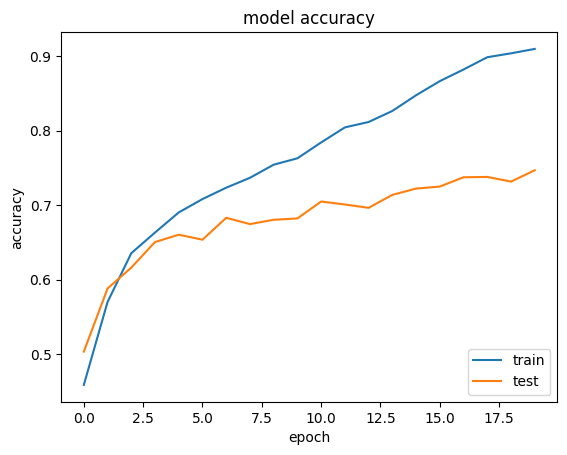

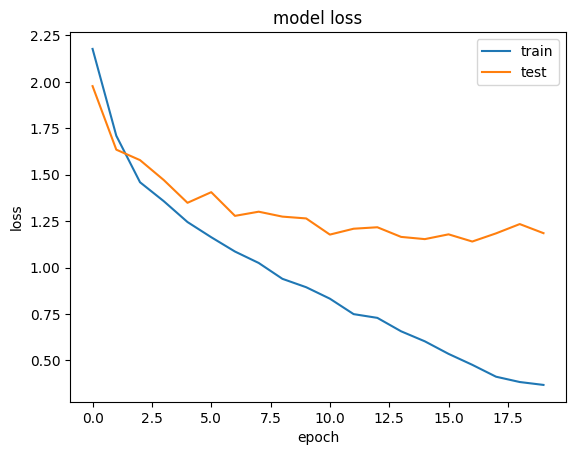

In [ ]:
plot_train_results(modelo4_fit)

In [ ]:
loss_L, acc_L = modelo4.evaluate(reuters_test_x_300, reuters_test_y_cat)

print('Precision: {}'.format(acc_L),'\t'*2, 'Perdida(loss): {}'.format(loss_L))



71/71 [==============================] - 2s 24ms/step - loss: 1.1853 - accuracy: 0.7467
Precision: 0.7466607093811035 		 Perdida(loss): 1.1853277683258057


Comentar finalmente que **las curvas siguen su progreso correspondiente, aunque parecen estar cerca de su máximo/mínimo,con lo cual parece que con más epochs se conseguirían mejores resultados**

